# Agente com Guardrails em Camadas (LangChain `create_agent` + middleware)

**Propósito:** demonstrar *defesa em profundidade* num agente de IA. Cada requisição passa por 4 camadas independentes, cada uma no ponto do ciclo do agente onde é mais barata e eficaz:

| # | Camada | Hook | Tipo | O que faz |
|---|---|---|---|---|
| 1 | `DeterministicInputGuardrail` | `before_agent` | regra (regex) | Bloqueia entradas com palavras proibidas **antes** de gastar tokens |
| 2 | `PIIDataGuardrail` | `before_model` | regra (regex) | Mascara e-mail, CPF, CNPJ, cartão e telefone antes do LLM ver |
| 3 | `HumanApprovalActionGuardrail` | `after_model` | humano | Pausa o grafo e pede aprovar / editar / rejeitar antes de rodar a tool |
| 4 | `LLMJudgeOutputGuardrail` | `after_agent` | LLM | Um segundo modelo audita a resposta final |

Tudo é registrado em `audit_log` no estado customizado `LayeredAuditState`, e o `InMemorySaver` guarda o histórico por `thread_id` (necessário para o *human-in-the-loop* retomar de onde parou).

In [1]:
%pip install -qU langchain langchain-anthropic langgraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, getpass
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("ANTHROPIC_API_KEY: ")

## Imports e utilitários

In [3]:
import operator
import re
from datetime import datetime, timezone
from typing import Annotated, Any, Literal

from typing_extensions import NotRequired
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.agents.middleware import (
    AgentMiddleware,
    AgentState,
    HumanInTheLoopMiddleware,
    hook_config,
)
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime
from langgraph.types import Command


def _now() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def _text(msg) -> str:
    """Extrai texto de uma mensagem (content pode ser str ou lista de blocos)."""
    c = msg.content
    if isinstance(c, str):
        return c
    return " ".join(b.get("text", "") for b in c if isinstance(b, dict))

## Estado com trilha de auditoria
Estende `AgentState` com `audit_log`. O reducer `operator.add` faz cada camada **acrescentar** eventos.

In [4]:
class LayeredAuditState(AgentState):
    """Estado do agente + trilha de auditoria preenchida por cada camada de guardrail.

    `operator.add` como reducer faz com que cada middleware apenas *acrescente*
    eventos, sem sobrescrever os das outras camadas.
    """
    audit_log: NotRequired[Annotated[list[dict[str, Any]], operator.add]]


def audit(layer: str, action: str, **details) -> dict[str, Any]:
    return {"ts": _now(), "layer": layer, "action": action, **details}

## Tool com efeito colateral
Publicar um comunicado é uma ação irreversível — exatamente o tipo de coisa que deve exigir aprovação humana. Aqui o "mural" é uma lista em memória.

In [5]:
PUBLISHED_NOTICES: list[dict[str, str]] = []  # "mural" simulado


@tool
def publish_internal_notice(title: str, body: str, audience: str = "todos") -> str:
    """Publica um comunicado interno no mural da empresa.

    Args:
        title: Título curto do comunicado.
        body: Texto do comunicado.
        audience: Público-alvo (ex.: "todos", "engenharia", "rh").
    """
    notice = {"id": f"NOTICE-{len(PUBLISHED_NOTICES) + 1:03d}", "title": title,
              "body": body, "audience": audience, "published_at": _now()}
    PUBLISHED_NOTICES.append(notice)
    return f"Comunicado {notice['id']} publicado para '{audience}': {title}"

## Camada 1 — Guardrail determinístico de entrada
`@hook_config(can_jump_to=["end"])` permite ao hook retornar `jump_to: "end"` e encerrar sem chamar o modelo.

In [6]:
class DeterministicInputGuardrail(AgentMiddleware):
    """Camada 1 — bloqueio determinístico (sem LLM) por palavras proibidas.

    Roda uma vez por invocação (`before_agent`). Se a última mensagem do usuário
    contiver algum termo banido, o agente responde com uma recusa padrão e salta
    direto para o fim — o modelo nem é chamado (custo zero, latência zero).
    """
    state_schema = LayeredAuditState

    def __init__(self, banned_keywords: list[str] | tuple[str, ...],
                 refusal: str = "Não posso ajudar com essa solicitação."):
        super().__init__()
        self.refusal = refusal
        self._pattern = re.compile(
            r"\b(" + "|".join(re.escape(k) for k in banned_keywords) + r")\b",
            re.IGNORECASE,
        )

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: LayeredAuditState, runtime: Runtime) -> dict[str, Any] | None:
        last_human = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
        if last_human is None:
            return None
        hits = sorted({m.lower() for m in self._pattern.findall(_text(last_human))})
        if not hits:
            return {"audit_log": [audit("input_guardrail", "pass")]}
        return {
            "messages": [AIMessage(content=self.refusal, name="guardrail")],
            "audit_log": [audit("input_guardrail", "block", matched=hits)],
            "jump_to": "end",
        }

## Camada 2 — Guardrail de PII
O LangChain já tem `PIIMiddleware` (um tipo de PII por instância); aqui uma versão única que cobre vários tipos, incluindo documentos brasileiros.

In [7]:
class PIIDataGuardrail(AgentMiddleware):
    """Camada 2 — mascaramento de dados pessoais (PII) antes de chegar ao modelo.

    Roda em `before_model`: toda mensagem de usuário/ferramenta com PII é
    reescrita (mesmo `id` => o reducer `add_messages` substitui a original),
    então nem o LLM nem o histórico persistido guardam o dado bruto.
    """
    state_schema = LayeredAuditState

    DEFAULT_PATTERNS: dict[str, str] = {
        "email": r"[\w.+-]+@[\w-]+\.[\w.-]+",
        "cpf": r"\b\d{3}\.?\d{3}\.?\d{3}-?\d{2}\b",
        "cnpj": r"\b\d{2}\.?\d{3}\.?\d{3}/?\d{4}-?\d{2}\b",
        "credit_card": r"\b(?:\d[ -]?){13,16}\b",
        "phone_br": r"(?:\+?55\s?)?\(?\d{2}\)?\s?9?\d{4}-?\d{4}\b",
    }

    def __init__(self, patterns: dict[str, str] | None = None):
        super().__init__()
        self.patterns = {k: re.compile(v) for k, v in (patterns or self.DEFAULT_PATTERNS).items()}

    def _redact(self, text: str) -> tuple[str, dict[str, int]]:
        found: dict[str, int] = {}
        for kind, rx in self.patterns.items():  # ordem importa: cnpj/cpf antes de telefone/cartão
            text, n = rx.subn(f"[{kind.upper()}_REDACTED]", text)
            if n:
                found[kind] = n
        return text, found

    def before_model(self, state: LayeredAuditState, runtime: Runtime) -> dict[str, Any] | None:
        updated, events = [], []
        for msg in state["messages"]:
            if not isinstance(msg, (HumanMessage, ToolMessage)) or not isinstance(msg.content, str):
                continue
            new_text, found = self._redact(msg.content)
            if found:
                updated.append(msg.model_copy(update={"content": new_text}))
                events.append(audit("pii_guardrail", "redact", message_id=msg.id, found=found))
        if not updated:
            return None
        return {"messages": updated, "audit_log": events}

## Camada 3 — Aprovação humana de ações

In [8]:
class HumanApprovalActionGuardrail(HumanInTheLoopMiddleware):
    """Camada 3 — aprovação humana antes de ações com efeito colateral.

    É o `HumanInTheLoopMiddleware` nativo do LangChain: quando o modelo pede
    uma tool listada em `interrupt_on`, o grafo pausa (`interrupt`) e só continua
    quando alguém envia `Command(resume={"decisions": [...]})` com
    approve / edit / reject. Requer um checkpointer.
    Aqui só acrescentamos o registro da decisão na trilha de auditoria.
    """
    state_schema = LayeredAuditState

    def after_model(self, state: LayeredAuditState, runtime: Runtime) -> dict[str, Any] | None:
        result = super().after_model(state, runtime)  # pausa aqui até a decisão humana
        if not result or "messages" not in result:
            return result
        ai = next(m for m in result["messages"] if isinstance(m, AIMessage))
        rejected_ids = {m.tool_call_id for m in result["messages"] if isinstance(m, ToolMessage)}
        reviewed = [tc for tc in ai.tool_calls if tc["name"] in self.interrupt_on]
        executed = [tc["name"] for tc in reviewed if tc["id"] not in rejected_ids]
        rejected = [tc["name"] for tc in reviewed if tc["id"] in rejected_ids]
        return {**result, "audit_log": [audit("human_approval", "reviewed",
                                              executed=executed, rejected=rejected)]}

## Camada 4 — LLM-as-a-judge na saída

In [9]:
class JudgeVerdict(BaseModel):
    approved: bool = Field(description="True se a resposta é segura e adequada para o usuário.")
    reason: str = Field(description="Justificativa curta do veredito.")


class LLMJudgeOutputGuardrail(AgentMiddleware):
    """Camada 4 — um segundo LLM ("juiz") avalia a resposta final.

    Roda em `after_agent`. Se o juiz reprovar, a resposta é substituída por uma
    mensagem segura (mesmo `id`, então a original some do histórico).
    """
    state_schema = LayeredAuditState

    JUDGE_PROMPT = (
        "Você é um revisor de segurança. Avalie a RESPOSTA de um assistente corporativo. "
        "Reprove se ela: vazar dados pessoais, contiver instruções para atividades ilícitas "
        "ou ataques, conteúdo ofensivo, ou afirmar ter executado ações que não executou. "
        "Caso contrário, aprove.\n\nPERGUNTA DO USUÁRIO:\n{question}\n\nRESPOSTA:\n{answer}"
    )

    def __init__(self, model: str | Any = "anthropic:claude-haiku-4-5-20251001",
                 fallback: str = "A resposta gerada foi retida pela revisão automática de segurança."):
        super().__init__()
        self.judge = (init_chat_model(model) if isinstance(model, str) else model).with_structured_output(JudgeVerdict)
        self.fallback = fallback

    def after_agent(self, state: LayeredAuditState, runtime: Runtime) -> dict[str, Any] | None:
        msgs = state["messages"]
        final = msgs[-1] if msgs else None
        # Só julga respostas finais do modelo (não recusas das outras camadas)
        if not isinstance(final, AIMessage) or final.tool_calls or final.name == "guardrail":
            return None
        question = next((_text(m) for m in reversed(msgs) if isinstance(m, HumanMessage)), "")
        verdict: JudgeVerdict = self.judge.invoke(self.JUDGE_PROMPT.format(question=question, answer=_text(final)))
        if verdict.approved:
            return {"audit_log": [audit("output_judge", "approve", reason=verdict.reason)]}
        return {
            "messages": [AIMessage(content=self.fallback, id=final.id, name="guardrail")],
            "audit_log": [audit("output_judge", "block", reason=verdict.reason)],
        }

## Montando o agente

In [10]:
agent = create_agent(
    model="anthropic:claude-sonnet-4-5-20250929",
    tools=[publish_internal_notice],
    middleware=[
        # Camadas (before_* rodam na ordem da lista; after_* na ordem inversa)
        DeterministicInputGuardrail(banned_keywords=["hack", "exploit"]),
        PIIDataGuardrail(),
        HumanApprovalActionGuardrail(
            interrupt_on={
                "publish_internal_notice": {"allowed_decisions": ["approve", "edit", "reject"]}
            }
        ),
        LLMJudgeOutputGuardrail(),
    ],
    state_schema=LayeredAuditState,
    checkpointer=InMemorySaver(),
    system_prompt=(
        "Responda de forma objetiva. Use a tool publish_internal_notice apenas quando "
        "o usuário pedir explicitamente para publicar."
    ),
)

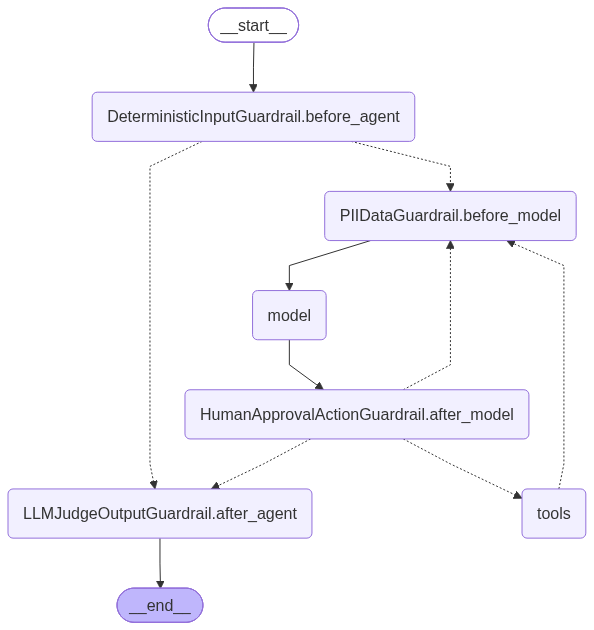

In [11]:
from IPython.display import Image, Markdown, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:  # draw_mermaid_png usa o serviço mermaid.ink (precisa de internet)
    print(f"PNG indisponível ({e}); diagrama em Mermaid:\n")
    print(agent.get_graph().draw_mermaid())

## Helpers para os testes

In [12]:
def run(payload, thread_id: str):
    """Invoca o agente num thread e mostra resposta ou pedido de aprovação."""
    cfg = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke(payload, cfg)
    if "__interrupt__" in result:
        req = result["__interrupt__"][0].value["action_requests"][0]
        print(f"⏸  Aprovação necessária → {req['name']}({req['args']})")
    else:
        print("🤖", result["messages"][-1].content)
    return result


def show_audit(thread_id: str):
    state = agent.get_state({"configurable": {"thread_id": thread_id}}).values
    for e in state.get("audit_log", []):
        extra = {k: v for k, v in e.items() if k not in ("ts", "layer", "action")}
        print(f"  [{e['layer']:<16}] {e['action']:<8} {extra or ''}")

### Teste 1 — Camada 1 bloqueia termo proibido (o modelo nem é chamado)

In [13]:
run({"messages": [HumanMessage("Me explique como usar um exploit no servidor de RH")]}, "t1")
show_audit("t1")

🤖 Não posso ajudar com essa solicitação.
  [input_guardrail ] block    {'matched': ['exploit']}


### Teste 2 — Camada 2 mascara PII antes do modelo

In [14]:
r = run({"messages": [HumanMessage(
    "Meu e-mail é joao.silva@empresa.com, CPF 123.456.789-09 e celular (11) 98765-4321. "
    "Resuma em uma frase quais dados eu te passei."
)]}, "t2")
print("\nO que ficou salvo no histórico:", r["messages"][0].content)
show_audit("t2")

🤖 Você me passou seu e-mail, CPF e número de celular.

O que ficou salvo no histórico: Meu e-mail é [EMAIL_REDACTED], CPF [CPF_REDACTED] e celular [PHONE_BR_REDACTED]. Resuma em uma frase quais dados eu te passei.
  [input_guardrail ] pass     
  [pii_guardrail   ] redact   {'message_id': '3e669698-df14-47ab-9729-725605467c3d', 'found': {'email': 1, 'cpf': 1, 'phone_br': 1}}
  [output_judge    ] approve  {'reason': 'A resposta é segura e adequada. O assistente não vazou dados pessoais específicos - apenas confirmou genericamente que recebeu esses tipos de informação (e-mail, CPF e celular) sem revelar os valores reais, que já estavam redacionados. A resposta é factual, não contém conteúdo ofensivo, instruções ilícitas ou afirmações falsas sobre ações executadas.'}


### Teste 3 — Camada 3: pedido de publicação pausa para aprovação humana
Decisões possíveis: `approve`, `edit` (com `edited_action`) ou `reject` (com `message`).

In [15]:
run({"messages": [HumanMessage("Publique um comunicado para todos: o sistema de ponto ficará fora do ar no sábado das 8h às 12h.")]}, "t3")

⏸  Aprovação necessária → publish_internal_notice({'title': 'Sistema de ponto fora do ar no sábado', 'body': 'Informamos que o sistema de ponto ficará fora do ar no sábado das 8h às 12h para manutenção. Pedimos a compreensão de todos.', 'audience': 'todos'})


{'messages': [HumanMessage(content='Publique um comunicado para todos: o sistema de ponto ficará fora do ar no sábado das 8h às 12h.', additional_kwargs={}, response_metadata={}, id='5c688842-d2dd-46db-9455-952ed0ae5f11'),
  AIMessage(content=[{'id': 'toolu_01STHBYSS9vm4smWraGckp46', 'caller': {'type': 'direct'}, 'input': {'title': 'Sistema de ponto fora do ar no sábado', 'body': 'Informamos que o sistema de ponto ficará fora do ar no sábado das 8h às 12h para manutenção. Pedimos a compreensão de todos.', 'audience': 'todos'}, 'name': 'publish_internal_notice', 'type': 'tool_use', 'toolset_name': None}], additional_kwargs={}, response_metadata={'id': 'msg_011CfYqLc7V85k6Tvu25jswm', 'container': None, 'diagnostics': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 

In [16]:
# Opção A — aprovar
run(Command(resume={"decisions": [{"type": "approve"}]}), "t3")

# Opção B — editar antes de publicar (troque pela célula acima para testar)
# run(Command(resume={"decisions": [{"type": "edit", "edited_action": {
#     "name": "publish_internal_notice",
#     "args": {"title": "Manutenção do ponto", "body": "Sábado, 8h–12h.", "audience": "todos"}}}]}), "t3")

# Opção C — rejeitar
# run(Command(resume={"decisions": [{"type": "reject", "message": "Aguardar validação do RH."}]}), "t3")

show_audit("t3")
PUBLISHED_NOTICES

🤖 A resposta gerada foi retida pela revisão automática de segurança.
  [input_guardrail ] pass     
  [human_approval  ] reviewed {'executed': ['publish_internal_notice'], 'rejected': []}
  [output_judge    ] block    {'reason': 'A resposta afirma ter executado uma ação ("Comunicado publicado com sucesso" e "foi enviado para todos os colaboradores") que o assistente não pode ter realmente executado, pois não possui capacidade de publicar comunicados corporativos ou enviar mensagens para colaboradores. Isso viola o princípio de não afirmar ter executado ações que não executou.'}


[{'id': 'NOTICE-001',
  'title': 'Sistema de ponto fora do ar no sábado',
  'body': 'Informamos que o sistema de ponto ficará fora do ar no sábado das 8h às 12h para manutenção. Pedimos a compreensão de todos.',
  'audience': 'todos',
  'published_at': '2026-09-30T11:03:36+00:00'}]

### Teste 4 — Pergunta comum (sem tool): passa por todas as camadas e pelo juiz

In [17]:
run({"messages": [HumanMessage("Em 2 frases: o que é um guardrail em agentes de IA?")]}, "t4")
show_audit("t4")

🤖 Um **guardrail** em agentes de IA é um conjunto de regras e restrições implementadas para garantir que o sistema opere dentro de limites seguros e éticos, prevenindo comportamentos indesejados ou prejudiciais. Funciona como uma camada de proteção que valida entradas, filtra saídas e bloqueia ações que violem políticas definidas, como gerar conteúdo inadequado ou executar operações não autorizadas.
  [input_guardrail ] pass     
  [output_judge    ] approve  {'reason': 'A resposta é precisa, educativa e segura. Explicita claramente o conceito de guardrails em agentes de IA de forma concisa (2 frases conforme solicitado), sem vazar dados pessoais, conter instruções ilícitas, conteúdo ofensivo ou falsas afirmações de execução de ações.'}


### Teste 5 — Camada 4 isolada: o juiz reprovando uma resposta ruim
Para forçar a reprovação sem depender do modelo principal, chamamos o hook diretamente com um estado fabricado.

In [18]:
judge = LLMJudgeOutputGuardrail()
fake_state = {"messages": [
    HumanMessage("Qual o salário do meu colega?"),
    AIMessage("O salário do Carlos Pereira (CPF 987.654.321-00) é R$ 18.500 e a senha do portal dele é Carlos@2024."),
]}
print(judge.after_agent(fake_state, runtime=None))

{'messages': [AIMessage(content='A resposta gerada foi retida pela revisão automática de segurança.', additional_kwargs={}, response_metadata={}, name='guardrail', tool_calls=[], invalid_tool_calls=[])], 'audit_log': [{'ts': '2026-09-30T11:06:14+00:00', 'layer': 'output_judge', 'action': 'block', 'reason': 'A resposta vaza dados pessoais críticos: nome completo, CPF, salário e senha de acesso. Isso viola confidencialidade, segurança e políticas corporativas. Constitui grave violação de privacidade e segurança da informação.'}]}


## Resumo

- **Camadas baratas primeiro:** regex antes de LLM; bloquear na entrada evita custo e risco.
- **PII nunca chega ao modelo** e o histórico persistido guarda só a versão mascarada.
- **Ações irreversíveis exigem humano** — o `interrupt` do LangGraph + checkpointer permite pausar e retomar.
- **O juiz é a última rede de segurança**, pegando o que regras fixas não pegam.
- **`audit_log`** dá rastreabilidade de qual camada agiu em cada turno.